In [1]:
import os
from dotenv import load_dotenv

if os.environ.get("OPENAI_API_KEY"):
    print("OPENAI_API_KEY is available")
else:
    raise ValueError("OPENAI_API_KEY is not available")

print()

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model = "gpt-5.4-nano",
    temperature = 0.7
)

llm

OPENAI_API_KEY is available



ChatOpenAI(output_version=None, profile={'name': 'GPT-5.4 nano', 'release_date': '2026-03-17', 'last_updated': '2026-03-17', 'open_weights': False, 'max_input_tokens': 400000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000016E947D94F0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000016E94DCFB00>, root_client=<openai.OpenAI object at 0x0000016E947DAA80>, root_async_client=<openai.AsyncOpenAI object at 0x0000016E94A79CA0>, model_name='gpt-5.4-nano', model_kwargs={

### **Pydantic Schema**

In [2]:
from pydantic import BaseModel, Field

class GraphSchema(BaseModel):

    topic : str = Field(description= "the topic of the graph")
    post: str = Field(description = "The LinkedIn post content")
    curated_post: str = Field(description = "The curated LinkedIn post content")

demo_obj = GraphSchema(
    topic = "The imporatance of AI in digital era",
    post = "AI is ............",
    curated_post = "The AI will be ............"
)

demo_obj

GraphSchema(topic='The imporatance of AI in digital era', post='AI is ............', curated_post='The AI will be ............')

In [3]:
def create_post(state : GraphSchema) -> GraphSchema:

    # Convert pytantic scema into a dictionary
    state = state.model_dump()

    # Extract the topics from the state
    topic = state["topic"]

    # passing the topic into llm to generate the post
    post = llm.invoke(f"Genrate the LinkedIn post about {topic}").content

    # Update the post with generated post
    state["post"] = post

    return state

In [4]:
def curate_post(state: GraphSchema) -> GraphSchema:

    # convert pydantic scema into dict
    state = state.model_dump()

    # Extract the topics from the state
    post = state["post"]

    # Curate the post
    curated_post = llm.invoke(f"curate the post with real world examples: {post}")

    state["curated_post"] = curated_post

    return state



In [5]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(GraphSchema)

# Create Node
graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

# Create Edge
graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

pydantic_graph = graph.compile()

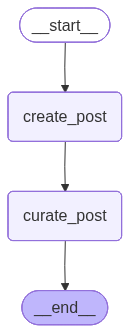

In [7]:
from IPython.display import Image, display

Image(pydantic_graph.get_graph().draw_mermaid_png())

In [8]:
pydantic_graph.invoke(
    {
        "topic": "The most important one langgraph interview question answer",
        "post":"",
        "curated_post": ""
    }
)

{'topic': 'The most important one langgraph interview question answer',
 'post': 'Absolutely—here’s a LinkedIn-style post you can copy/paste. (I’m assuming you mean the *most important* question asked in a LangGraph interview and the *best answer*.)\n\n---\n\n🔥 **One LangGraph interview question (that actually matters):**  \n**“How do you design a graph-based agent with LangGraph—especially managing state and control flow?”**\n\n✅ **The best answer:**  \nIn LangGraph, the core idea is that an agent isn’t just a single prompt—it’s a **stateful workflow**. You design a **graph of nodes** where each node performs a step (like LLM reasoning, tool calling, retrieval, validation, etc.).  \n\nThe key to doing it correctly is:  \n1. **Define the State** (what data moves through the graph—messages, intermediate results, decisions).  \n2. **Create Nodes** for each action step (LLM, tool execution, checks).  \n3. **Use edges/conditional routing** to control flow (e.g., stop when the answer is goo